# **Time Series Analysis**

## Import necessary libraries

In [2]:
import numpy as np 
import matplotlib as mpl 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Load the dataset 

In [3]:
df=pd.read_csv(r'D:\fsds\practice_codes\deep_learning\time_series\Dataset\AirPassengers.csv')

df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
# lets rename the columns to 'Date' and 'No of Passengers'
df.columns=['Date','No of Passengers']
df.head()

,Date,No of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## Visualize the Time Series

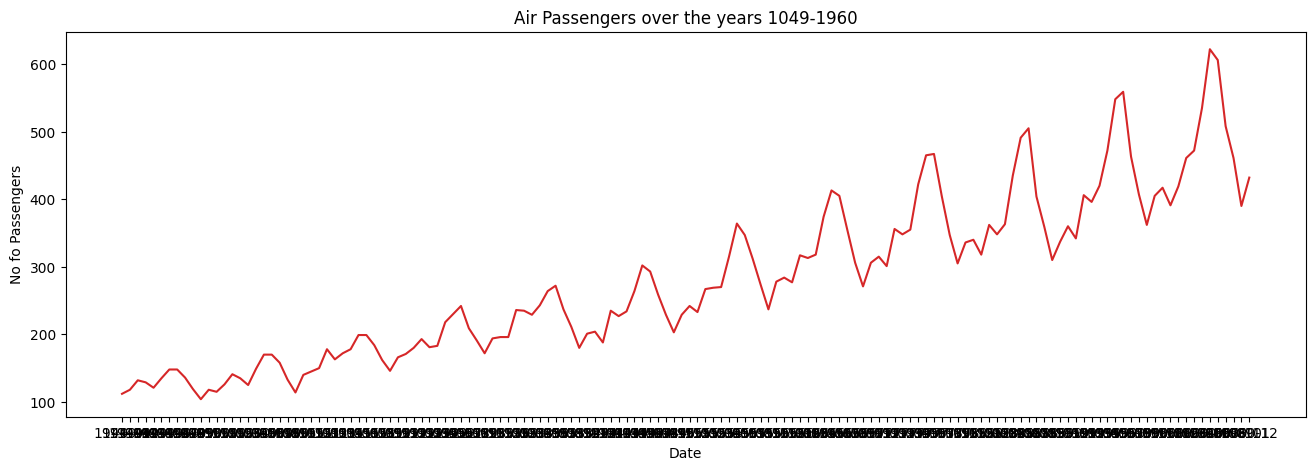

In [5]:
def plot_df(df, x, y, title='', xlabel='Date', ylabel='No fo Passengers', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x,y,color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(df, x=df['Date'], y=df['No of Passengers'], title='Air Passengers over the years 1049-1960')

### since all the values are positive, we can show this on both sides of Y axis to emphasize the growth

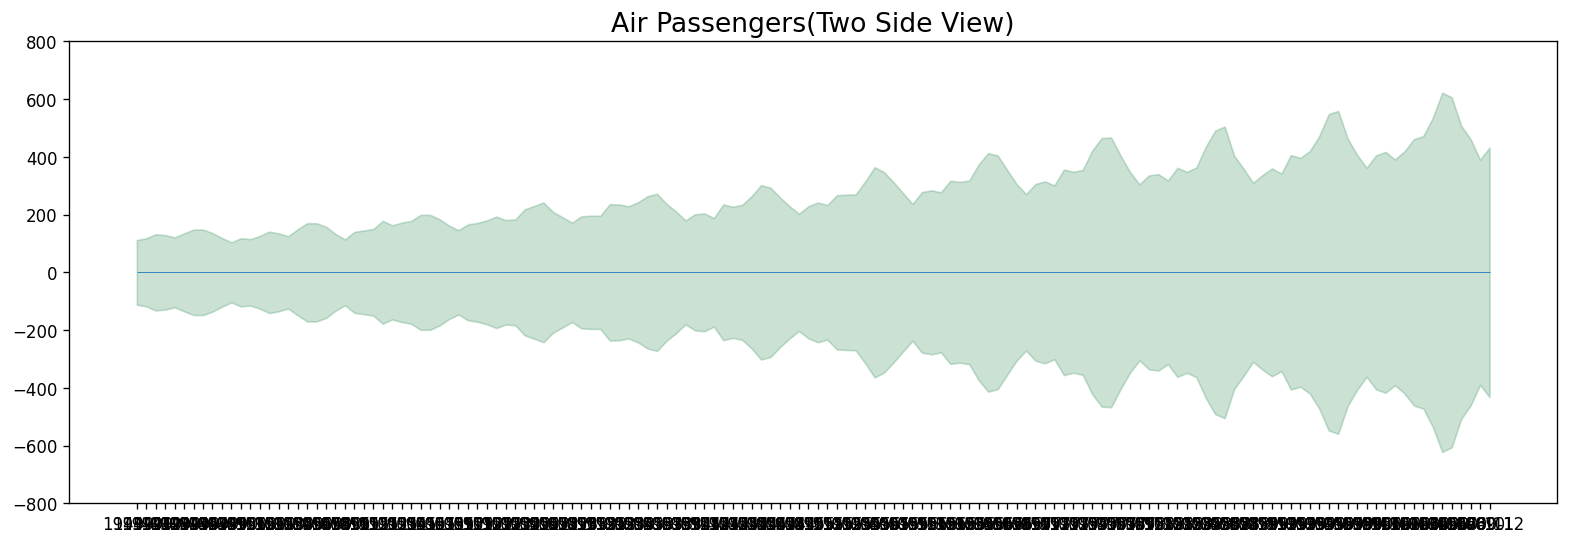

In [6]:
x=df['Date'].values
y=df['No of Passengers'].values

fig, ax = plt.subplots(1,1, figsize=(16,5), dpi=120)
plt.fill_between(x, y1=y, y2=-y, alpha=0.25, color='seagreen')
plt.ylim(-800,800)
plt.title('Air Passengers(Two Side View)', fontsize=16)
plt.hlines(y=0, xmin=np.min(df['Date']), xmax=np.max(df['Date']), linewidth=.5)
plt.show()


## Patterns in Time Series

#### Any time series visualization will have the following components:
- Trend
- Seasonality
- Cyclic
- Random

#### Trend is observed when there is an increasing or decreasing slope in the observed in the time series

#### Seasonality is observed when there is a distinct repeated pattern observed between regular intervals due to seasonal factors. It could be because of the month of the year, the day of the month, weekdays or even time of the day.

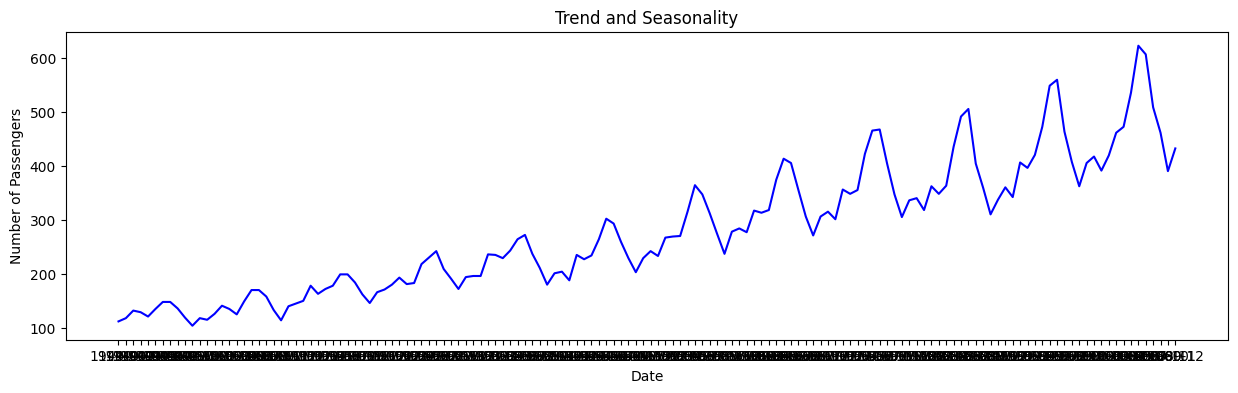

In [7]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Number of Passengers', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='blue')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()
    

plot_df(df, x=df['Date'], y=df['No of Passengers'], title='Trend and Seasonality')

#### Cyclic Behavior: happens when the rise and fall pattern in the series does not happen in fixed calendar-based intervals.
- Do not confuse 'cyclic' effect with 'seasonal' effect.
- If the patterns are not of fixed calendar based frequencies, then it is cyclic. Because, unlike the seasonality, cyclic effects are typically influenced by the business and other socio-economic factors.

## Decomposition of Time Series: 

#### Time series data (like stock prices, weather data, sales, etc.) often show patterns that can be separated into components. Decomposition is the process of breaking down a time series into these systematic parts plus some random noise.

#### Types of Decomposition Models:
- Additive Model:
    - is used when seasonal fluctuations are roughly constant over time.
        - Eg: Temperature variations around a steadily rising global average
    - Value = Base Level + Trend + Seasonality + Error
- Multiplicative Model:
    - is used when seasonal variations grow or shrink with the trend.
        - Eg: Sales growing every year, and seasonal peaks (like Diwali or Christmas) also getting bigger.
    - Value = Base Level x Trend x Seasonality x Error


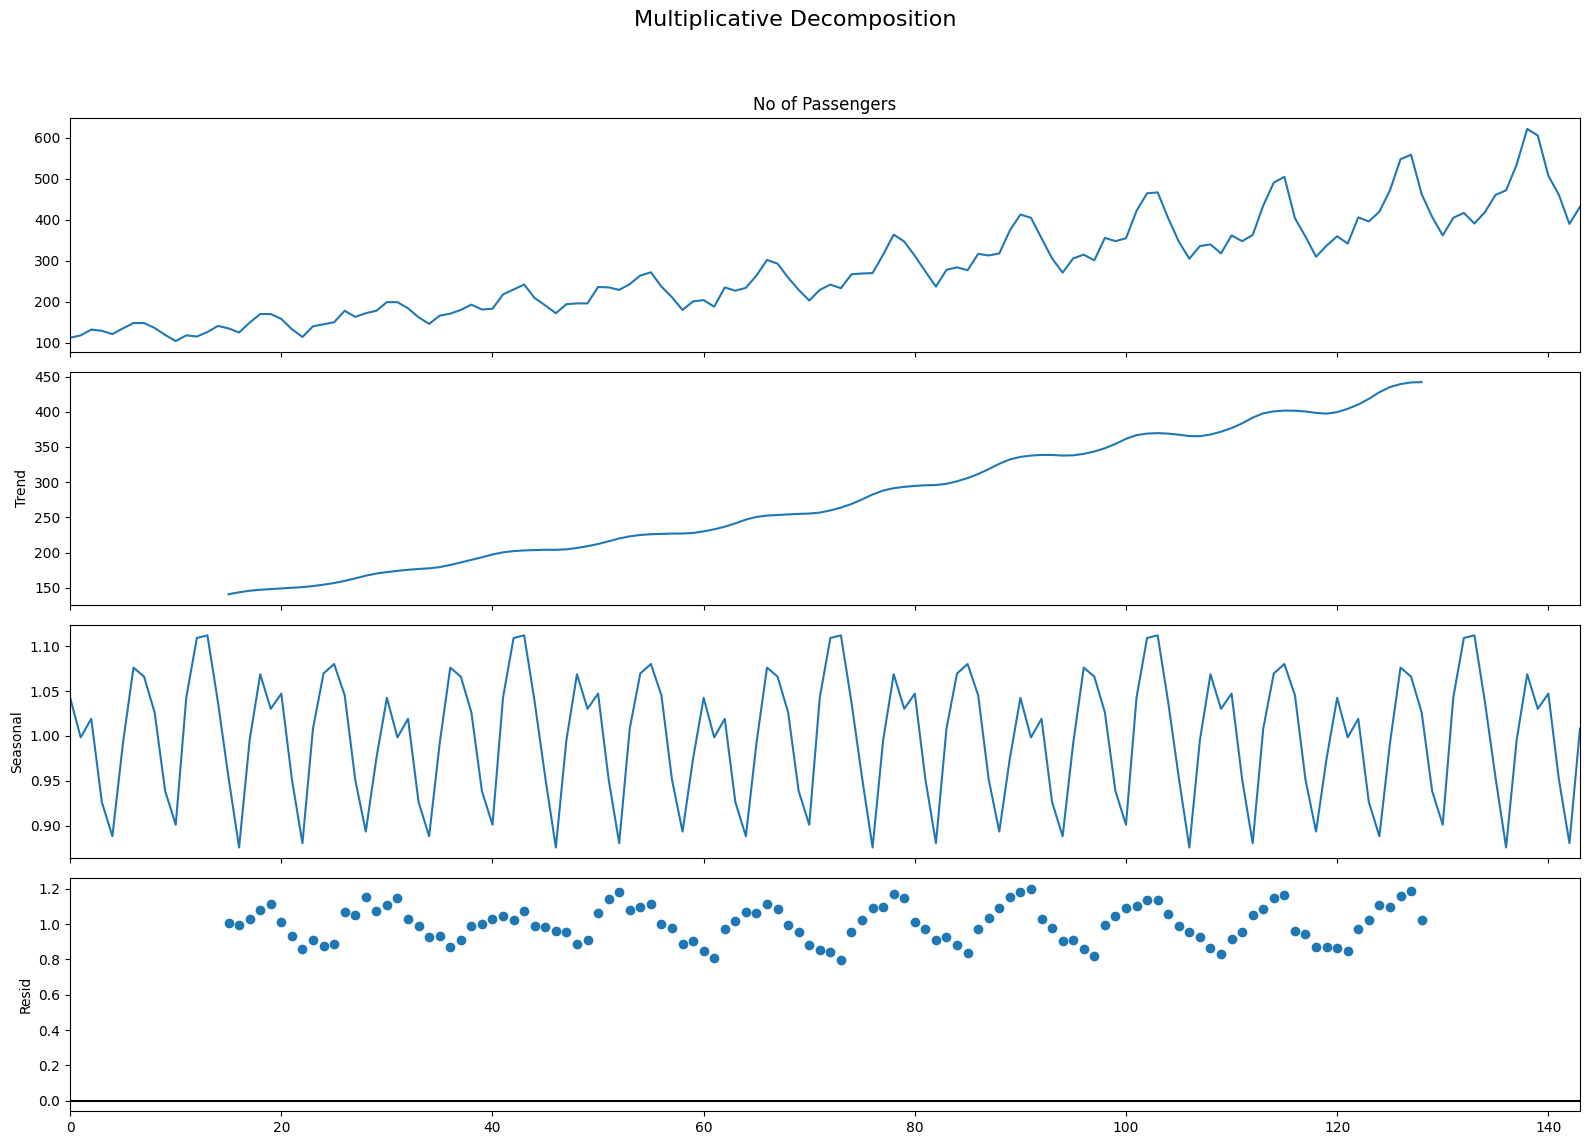

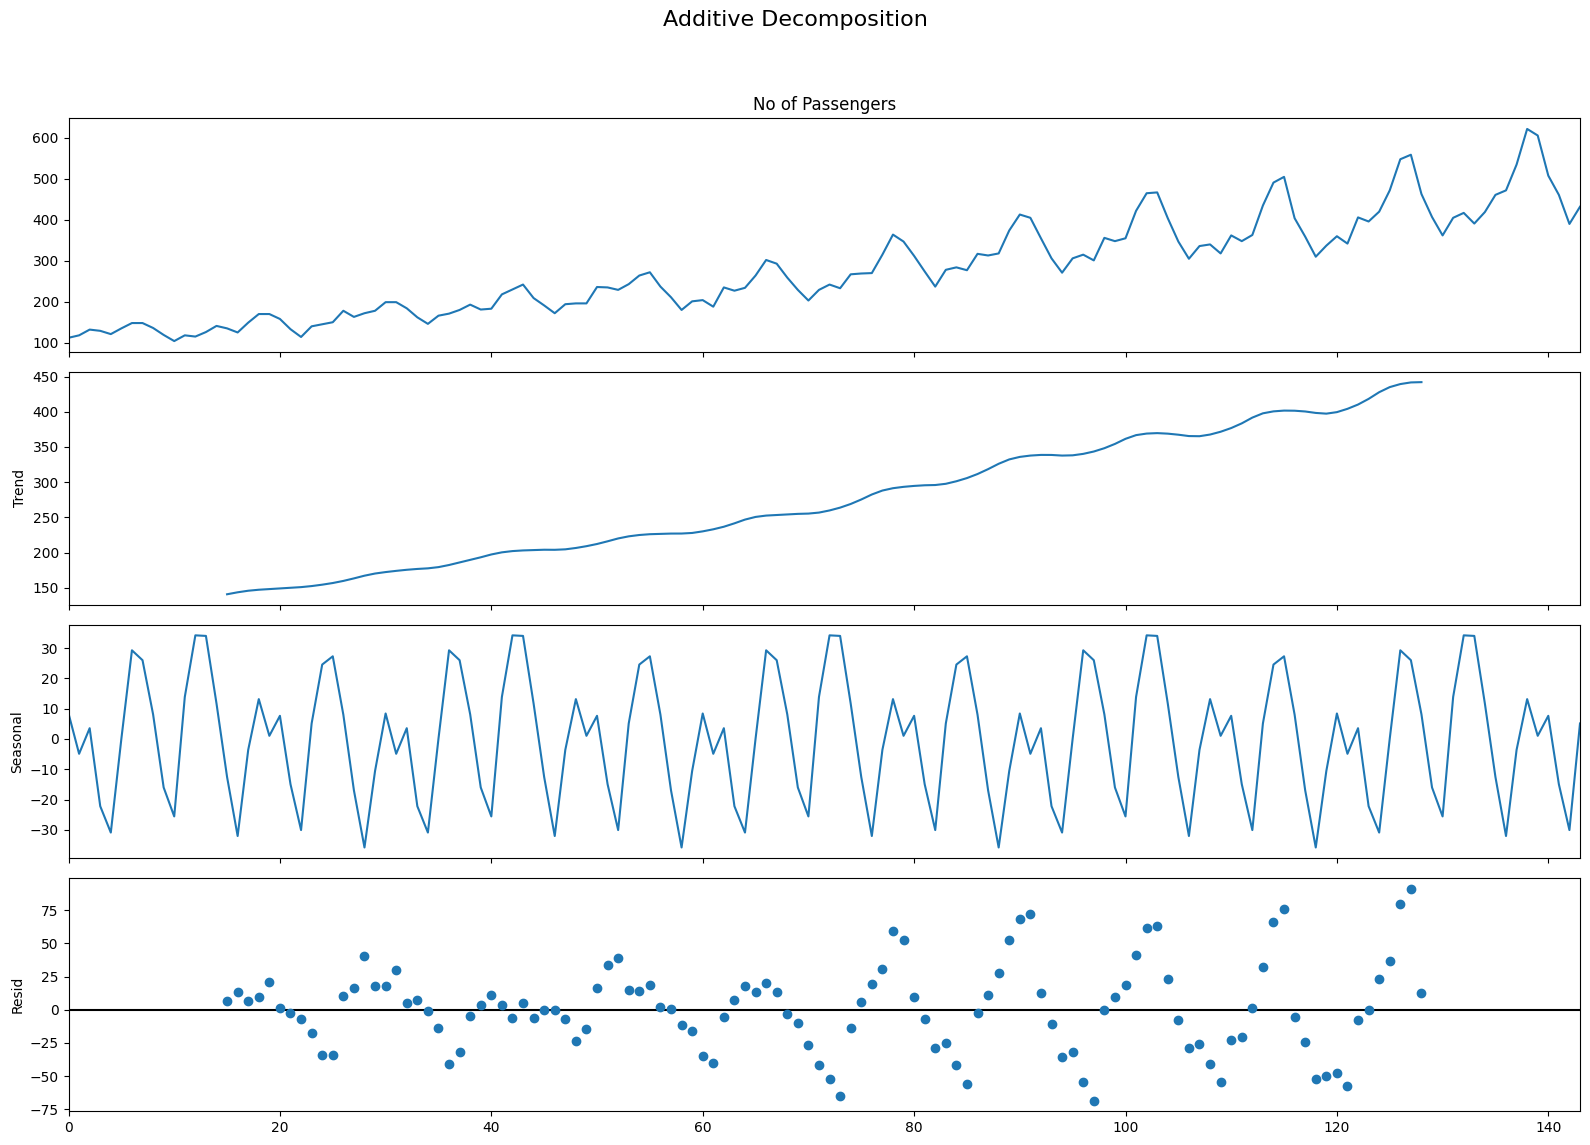

In [8]:
# seasonal_decompose in statsmodels implements this conveniently.
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parser


# Multiplicative decomposition
md=seasonal_decompose(df['No of Passengers'], model='multiplicative', period=30)

#Additive decomposition
ad=seasonal_decompose(df['No of Passengers'], model='additive', period=30)

plt.rcParams.update({'figure.figsize': (16,12)})
md.plot().suptitle('Multiplicative Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

ad.plot().suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

#### Why Decompose a Time Series?
- To understand underlying patterns.
- To forecast more accurately.
- To remove noise and focus on signal.
- To detect anomalies (unexpected spikes or drops).

## Stationary and Non Stationary Time Series
#### Stationarity is a property of a time series. 
- A stationary series is one where the values of the series is not a function of time. So, the values are independent of time.
- The statistical properties of the series like mean, variance and autocorrelation are constant over time.
- Autocorrelation of the series is nothing but the correlation of the series with its previous values.
- A stationary time series is independent of seasonal effects as well.

#### Below are the sample plots for stationary and non stationary time series

<img src="https://www.machinelearningplus.com/wp-content/uploads/2019/02/stationary-and-non-stationary-time-series-865x569.png?ezimgfmt=ng:webp/ngcb1" alt="Image" width="400"/>


## Difference Between White Noise and Stationary Series

- The only difference is that Mean is 0 for white noise.
- there are no patterns for white noise
- white noise in layman's terms is a sequence of completely random numbers with mean zero.

<Axes: title={'center': 'Random White Noise'}>

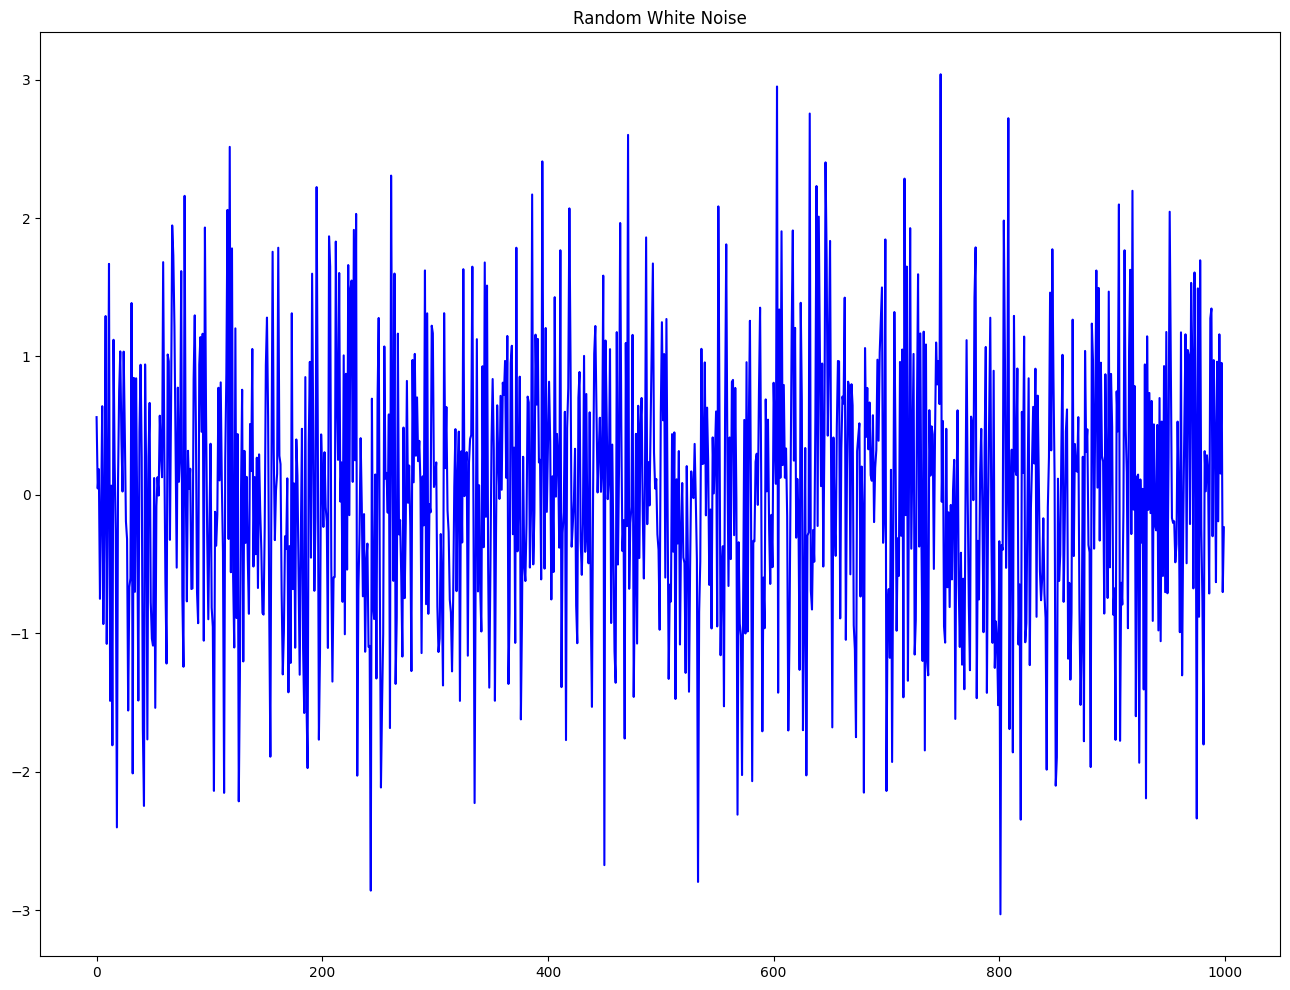

In [9]:
rand_numbers = np.random.randn(1000)
pd.Series(rand_numbers).plot(title='Random White Noise', color='b')